## Predicting Road Collision Severity in London: Integrating Network Centrality, Traffic Speed, and Deprivation (2020-2024)
### A Machine Learning Approach toward predicting accident severity 

---
> **Author:** Tee Chin Min Benjamin  
> **Module:** Data Science for Spatial Systems (DSSS) by Dr Huanfa Chen  
> **Word count (narrative only):** ~1,690 words

---
## 1. Introduction

Road traffic collisions are a leading cause of preventable death and serious injury. In London, despite a [Vision Zero strategy](https://www.london.gov.uk/programmes-strategies/transport/improving-londons-roads/vision-zero-london) targeting a 70% reduction in Killed or Seriously Injured (KSI) casualties by 2030, approximately 3,700 people were killed or seriously injured on roads in 2024, with nearly 60% comprising pedestrians and cyclists [(TfL, 2024)](https://content.tfl.gov.uk/casualties-in-greater-london-2024.pdf). KSI, defined within STATS19 as fatalities and injuries involving fracture, concussion, internal trauma, or inpatient hospitalisation, represents an area for critical attention. Understanding *which* collisions result in KSI outcomes and *why* has implications for infrastructure investment, emergency resource allocation, and targeted safety intervention.

KSI risk determinants are multi-dimensional. Speed limit, lighting, road surface, and junction characteristics emerge as primary severity predictors in ensemble modelling studies [(Tong, 2025)](https://arxiv.org/pdf/2512.04022). Deprivation compounds this, with pedestrians in the most deprived neighbourhoods facing higher KSI probability than those in least deprived areas [(Christie et al., 2019)](https://discovery.ucl.ac.uk/id/eprint/10206226/1/Inequalities%20in%20road%20safety%20outcomes%20Christie.pdf). 

Critically, [Sarkar, Webster & Kumari (2018)](https://www-tandfonline-com.libproxy.ucl.ac.uk/doi/epdf/10.1080/15568318.2017.1402972?needAccess=true) demonstrated in a Greater London study that street network topology, specifically betweenness centrality, divergence ratio, and hull radius, were associated with KSI odds alongside speed and deprivation, establishing that a location's structural position within the road network shapes severity outcomes. 

This study combines OpenStreetMap-derived centrality measures with STATS19, the Index of Multiple Deprivation, DfT AADF traffic counts, and LAEI 2022 road speed data to predict KSI outcomes across London (2020–2024). Three tree-based classifiers are evaluated under stratified cross-validation with Synthetic Minority Over-sampling Technique (SMOTE) [(Chawla et al., 2002)](https://arxiv.org/pdf/1106.1813), and model decisions interpreted with SHAP [(Lundberg & Lee, 2017)](https://arxiv.org/pdf/1705.07874) to surface key predictors of collision severity.

---
## 2. Research Question

**Primary Research Question:** To what extent do graph-derived network centrality measures, deprivation indicators, and casualty-level vulnerability factors jointly predict KSI outcomes in London road collisions (2020–2024)?

**Sub-questions:**

- **Network structure:** Do closeness and betweenness centrality independently predict elevated KSI risk after controlling for traffic volume, speed, and road environment, and does including graph features measurably improve model performance?

- **Deprivation:** Which aspects of deprivation (area-level, driver, or casualty) most strongly shape KSI severity outcomes?

- **Casualty vulnerability:** How do casualty characteristics such as mode of travel (pedestrian, cyclist, motorcyclist), age group, and collision complexity shape KSI probability?

---
## 3. Data

### 3.1 Data Sources

The analytical feature matrix was constructed from seven datasets. 

| Dataset | Source | Spatial Coverage | Temporal Coverage |
|---|---|---|---|
| STATS19 — Collisions | DfT / data.gov.uk | England & Wales | 2020–2024 |
| STATS19 — Vehicles | DfT / data.gov.uk | England & Wales | 2020–2024 |
| STATS19 — Casualties | DfT / data.gov.uk | England & Wales | 2020–2024 |
| London Road Network | OpenStreetMap via OSMnx | Greater London | Current |
| Index of Multiple Deprivation 2019 | MHCLG / data.gov.uk | England (LSOA) | 2019 |
| Traffic Count Points & AADF | DfT / roadtraffic.dft.gov.uk | Great Britain | 2000–2024 |
| LAEI 2022 — Road Speeds (Major & Minor) | GLA / data.london.gov.uk | Greater London | 2022 |

### 3.2 Data Preparation

Data was prepared using the following methods: 

| Category | Source / Method | Description & Preprocessing |
| :--- | :--- | :--- |
| Target Variable (KSI)| STATS19 (Greater London) | Binary classification: Severity 1 (Fatal) & 2 (Serious) aggregated into positive class; Severity 3 (Slight) as negative class. |
| Network Measures | Graph-based Centrality | Degree, betweenness, and closeness centrality; spatially snapped to nearest network node and joined to collision records. |
| Traffic Volume | DfT AADF (2020–2024) | Collisions were matched to nearest DfT traffic count point where total motor vehicle flow was log-transformed to normalize right-skewed distribution. |
| Road Speed Proxy | LAEI 2022 & Temporal Features | Proxy for impact speed using average operating speeds; integrated with diurnal features (hour/time-period). Although restricted-access [OS NGD Transport Network](https://www.ordnancesurvey.co.uk/products/os-ngd-api-features/transport) data offers higher-resolution link-level speeds, the LAEI-temporal approach provides a minimal accessible alternative for capturing impact-related risk |
| Deprivation | IMD 2019 Deciles | Three-dimensional socioeconomic context: `imd_decile` (location), `mean_driver_imd`, and `mean_casualty_imd`. |

### 3.3 Variables Selected

The final analytical feature set comprised 43 variables in 7 groups.

**Target variable**

| Variable | Type | Definition |
|---|---|---|
| `severity_binary` | Binary | 1 = KSI (Fatal or Serious); 0 = Slight. Derived from STATS19 `collision_severity` codes 1 and 2. |

**Graph centrality (3)**

| Variable | Type | Definition |
|---|---|---|
| `closeness_centrality` | Continuous | Reciprocal of mean shortest-path distance from node to all others; reflects network accessibility. |
| `betweenness_centrality` | Continuous | Proportion of all shortest paths passing through a node; reflects throughput load and conflict potential. |
| `degree_centrality` | Continuous | Number of edges connected to a node, normalised by maximum possible; reflects junction complexity. |

**Temporal (4)**

| Variable | Type | Definition |
|---|---|---|
| `hour_of_collision` | Integer | Hour of day (0–23); proxy for prevailing operating speeds and traffic state. |
| `time_period_enc` | Ordinal | AM peak / inter-peak / PM peak / night; captures systematic temporal severity patterns. |
| `year` |	Integer |	Collision year (2020–2024); captures long-term drift and structural changes in road safety. |
|`quarter` | Ordinal |	Calendar quarter (1–4); groups Jan-Mar, Apr-Jun, Jul-Sep, Oct-Dec to capture seasonal risk profiles.|

**Collision environment (9)**

| Variable | Type | Definition |
|---|---|---|
| `speed_limit` | Ordinal | Posted speed limit in mph (20–70). |
| `road_type` | Categorical | Roundabout, One-way street, single carriageway, dual carriageway, slip road |
| `first_road_class` | Categorical | Motorway, Major A-road, A-road, B-road, unclassified  |
| `junction_detail` | Categorical | Not at junction or within 20 meters, T or staggered, crossroads, 4 arm junction  |
| `junction_control` | Categorical | Traffic signals, give way, stop, uncontrolled. |
| `light_conditions` | Categorical | Daylight, darkness (lit / unlit / unknown lighting). |
| `weather_conditions` | Categorical | Fine, rain, snow, fog, high winds, etc. |
| `road_surface_conditions` | Categorical | Dry, wet, frost/ice, flood. |
| `pedestrian_crossing` | Categorical | Crossing facility type within 50 m of collision. |

**Deprivation — three dimensions (3)**

| Variable | Type | Definition |
|---|---|---|
| `imd_decile` | Ordinal | IMD 2019 decile of accident LSOA (1 = most deprived); captures road environment quality. |
| `mean_driver_imd` | Continuous | Mean IMD decile of drivers' home postcodes per collision; proxy for vehicle quality and risk behaviour. |
| `mean_casualty_imd` | Continuous | Mean IMD decile of casualties' home postcodes per collision; proxy for individual vulnerability. |

**Vehicle-level aggregates (12)**

| Variable | Type | Definition |
|---|---|---|
| `motorcycle_involved` | Binary | Any motorcycle or moped involved. |
| `hgv_involved` | Binary | Any heavy goods vehicle involved. |
| `cycle_involved` | Binary | Any pedal cycle involved. |
| `any_skid_overturn` | Binary | Any vehicle skidded or overturned. |
| `any_hit_offroad_object` | Binary | Any vehicle struck an off-road object (roadside barrier, tree, sign, etc.). |
| `any_left_carriageway` | Binary | Any vehicle left the carriageway. |
| `any_front_impact` | Binary | Any vehicle had a front-impact collision (head-on or rear-end). |
| `any_moving_vehicle` | Binary | At least one vehicle was moving at point of impact (vs. stationary). |
| `any_turning_vehicle` | Binary | At least one vehicle was executing a turn at point of impact. |
| `work_journey` | Binary | Any driver making a work or business journey at time of collision. |
| `mean_driver_age` | Continuous | Mean age of all drivers involved per collision. |
| `any_male_driver` | Binary | Any male driver involved; used as a risk behaviour proxy. |

**Casualty-level aggregates (9)**

| Variable | Type | Definition |
|---|---|---|
| `pedestrian_casualty` | Binary | At least one pedestrian casualty. |
| `motorcyclist_casualty` | Binary | At least one motorcyclist casualty. |
| `cyclist_casualty` | Binary | At least one cyclist casualty. |
| `child_casualty` | Binary | At least one casualty aged under 16. |
| `elderly_casualty` | Binary | At least one casualty aged 70 or over. |
| `min_casualty_age` | Integer | Age of youngest casualty; captures child involvement continuously. |
| `ped_on_crossing` | Binary | Pedestrian struck while on or near a marked crossing. |
| `ped_jaywalking` | Binary | Pedestrian struck along carriageway or crossing elsewhere |
| `n_casualties` | Integer | Total number of casualties per collision; measures collision severity scale. |

**Traffic volume and speed (3)**

| Variable | Type | Definition |
|---|---|---|
| `aadf_log` | Continuous | Log-transformed total annual average daily motor vehicle flow at nearest count point. |
| `accident_rate_clipped` | Continuous | Accidents per million vehicle-days at nearest count point (99th-percentile clipped). |
| `avg_speed_kph` | Continuous | LAEI 2022 average operating speed: major-road link speed (≤30 m match) or minor-road 1 km² grid fallback. |

### 3.4 Data Quality

The table summarises data completeness at each integration stage.

| Stage | Records | Notes |
|---|---|---|
| STATS19 national (2020–2024) | ~1,900,000 | England & Wales, all severities |
| Filtered to Greater London boundary | 109,024 | Point-in-polygon clip to GLA boundary |
| LAEI road speed assigned | 109,023 | 99.99% coverage; 1 record unmatched |
| AADF-matched (≤1,000 m count point) | 103,759 | 95.2% of London collisions |
| After feature dropna (final model) | 103,740 | 19 records dropped; 99.98% retention |
| — of which KSI (positive class) | ~16,391 | 15.8% KSI rate |
| — of which Slight (negative class) | ~87,349 | 84.2% slight rate |
| Training set (70%) | 72,618 | Stratified split; class balance preserved |
| Held-out test set (30%) | 31,122 | Stratified split; never used during training |

In [ ]:
# ── 3. Load Prepared Data ────────────────────────────────────────────────────
#
# Preprocessing of data (Sections 3.1–3.13) has been moved to data_preparation.py.
# To regenerate:   python data_preparation.py
#
# Outputs loaded:
#   gdf              — collision-level GeoDataFrame (EPSG:4326, ~109k rows)
#   casualties_ldn   — raw London casualty rows (for EDA)
#   centrality_df    — node-level centrality measures

import pandas as pd
import geopandas as gpd
import numpy as np
import osmnx as ox
import networkx as nx
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

CACHE_DIR  = Path('data')

# ── Load collision-level GeoDataFrame ────────────────────────────────────────
gdf = gpd.read_parquet(CACHE_DIR / 'gdf_prepared.geoparquet')
print(f"gdf loaded: {len(gdf):,} rows x {gdf.shape[1]} cols")
print(f"  CRS: {gdf.crs}")
print(f"  KSI rate: {gdf['severity_binary'].mean():.1%}")

# ── Load raw casualties for EDA ──────────────────────────────────────────────
casualties_ldn = pd.read_parquet(CACHE_DIR / 'casualties_ldn.parquet')
print(f"\ncasualties_ldn loaded: {len(casualties_ldn):,} rows")

# ── Load centrality (for reference/downstream use) ──────────────────────────
centrality_df = pd.read_parquet(CACHE_DIR / 'london_centrality.parquet')
print(f"centrality_df loaded: {len(centrality_df):,} nodes")

print(f"\nData loading complete. Ready for EDA and modelling.")

gdf loaded: 109,024 rows x 106 cols
  CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east"

In [32]:
# ── 4. FEATURE PREPARATION ────────────────────────────────────────────────────
#
# Assembles the full feature matrix from all data sources:
#   - Collision, vehicle, casualty features (Sections 3.3–3.9)
#   - Graph centrality (Section 3.10)
#   - AADF traffic volume & exposure rate (Section 3.11)
#   - LAEI average road speed (Section 3.12)
#
# Pruned feature set: removes near-perfect duplicates and zero-signal features
# identified during exploratory correlation analysis (|r| > 0.8 or |r_severity| < 0.002).

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    matthews_corrcoef, confusion_matrix, make_scorer,
    precision_recall_curve
)
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
import numpy as np, math

feature_cols = [
    # ── Graph centrality (3) ──────────────────────────────────────────────────
    'closeness_centrality', 'betweenness_centrality', 'degree_centrality',

    # ── Temporal (4) ──────────────────────────────────────────────────────────
    'hour_of_collision', 'time_period_enc', 'year', 'quarter',

    # ── Collision-level: road & environment (9) ──────────────────────────────
    'road_type', 'first_road_class', 'speed_limit', 'junction_detail', 'junction_control',
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    'pedestrian_crossing',
        
    # ── Deprivation — three distinct dimensions (3) ───────────────────────────
    'imd_decile',           # area-level (LSOA of accident)
    'mean_driver_imd',      # individual driver home postcode
    'mean_casualty_imd',    # individual casualty home postcode

    # ── Vehicle-level aggregates (12) ─────────────────────────────────────────
    'motorcycle_involved', 'hgv_involved', 'cycle_involved',
    'any_skid_overturn', 'any_hit_offroad_object', 'any_left_carriageway', 
    'any_front_impact', 'any_moving_vehicle', 'any_turning_vehicle',
    'work_journey', 'mean_driver_age', 'any_male_driver',

    # ── Casualty-level aggregates (9) ─────────────────────────────────────────
    'pedestrian_casualty', 'motorcyclist_casualty', 'cyclist_casualty',
    'child_casualty', 'elderly_casualty', 
    'min_casualty_age', 'ped_on_crossing', 'ped_jaywalking', 
    'n_casualties',

    # ── Traffic volume & speed (3) ─────────────────────────────────
    'aadf_log', 'accident_rate_clipped', 'avg_speed_kph',
]

# ── Step 0: Availability audit ────────────────────────────────────────────────
available = [c for c in feature_cols if c in gdf.columns]
missing   = [c for c in feature_cols if c not in gdf.columns]
print(f"Feature audit: {len(available)}/{len(feature_cols)} available")
if missing:
    print(f"  Missing (excluded): {missing}")
feature_cols = available
print(f"Final feature count: {len(feature_cols)}")

# ── Step 1: Filter to AADF-matched accidents with speed data ─────────────────
model_df = gdf[gdf['cp_matched']][feature_cols + ['severity_binary']].copy()
print(f"\nBefore dropna: {len(model_df):,} rows")
model_df = model_df.dropna()
print(f"After dropna:  {len(model_df):,} rows")
print(f"Class balance:\n{model_df['severity_binary'].value_counts(normalize=True).round(3)}")

# ── Step 2: Encode categorical columns ────────────────────────────────────────
cat_cols = [
    'road_type', 'first_road_class', 'junction_detail', 'junction_control',
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    'urban_or_rural_area', 'pedestrian_crossing',
    'time_period_enc',
]
cat_cols = [c for c in cat_cols if c in feature_cols]
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    label_encoders[col] = le
print(f"Encoded {len(cat_cols)} categorical columns")

# ── Step 3: Train / held-out test split (70/30, stratified) ──────────────────
X = model_df[feature_cols]
y = model_df['severity_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train):,} | Test (held-out): {len(X_test):,}")
print(f"Train class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test  class balance: {y_test.value_counts(normalize=True).round(3).to_dict()}")

# ── Feature group summary ──────────────────────────────────────────────────────
groups = {
    'Graph centrality':          ['closeness_centrality', 'betweenness_centrality', 'degree_centrality'],
    'Temporal':                  ['hour_of_collision', 'time_period_enc', 'year', 'quarter'],
    'Collision environment':     ['road_type', 'first_road_class', 'speed_limit', 'junction_detail', 'junction_control',
                                  'light_conditions', 'weather_conditions', 'road_surface_conditions',
                                  'pedestrian_crossing'],
    'Deprivation':               ['imd_decile', 'mean_driver_imd', 'mean_casualty_imd'],
    'Vehicle-level':             ['motorcycle_involved', 'hgv_involved', 'cycle_involved',
                                  'any_skid_overturn', 'any_hit_offroad_object', 'any_left_carriageway', 
                                  'any_front_impact', 'any_moving_vehicle', 'any_turning_vehicle',
                                  'work_journey', 'mean_driver_age', 'any_male_driver'],
    'Casualty-level':            ['pedestrian_casualty', 'motorcyclist_casualty', 'cyclist_casualty',
                                  'child_casualty', 'elderly_casualty', 
                                  'min_casualty_age', 'ped_on_crossing', 'ped_jaywalking', 
                                  'n_casualties'],
    'Traffic volume & speed':    ['aadf_log', 'accident_rate_clipped', 'avg_speed_kph'],
}

print(f"\nFeature groups:")
total = 0
for group, cols in groups.items():
    in_model = [c for c in cols if c in feature_cols]
    total   += len(in_model)
    print(f"  {group:<25s}: {len(in_model):2d} features")
print(f"  {'TOTAL':<25s}: {total:2d} features")


Feature audit: 43/43 available
Final feature count: 43

Before dropna: 103,759 rows
After dropna:  103,740 rows
Class balance:
severity_binary
0    0.842
1    0.158
Name: proportion, dtype: float64
Encoded 9 categorical columns

Train: 72,618 | Test (held-out): 31,122
Train class balance: {0: 0.842, 1: 0.158}
Test  class balance: {0: 0.842, 1: 0.158}

Feature groups:
  Graph centrality         :  3 features
  Temporal                 :  4 features
  Collision environment    :  9 features
  Deprivation              :  3 features
  Vehicle-level            : 12 features
  Casualty-level           :  9 features
  Traffic volume & speed   :  3 features
  TOTAL                    : 43 features


## 3.5. Exploratory Data Analysis (EDA)
EDA revealed the following distributional patterns: 

1. KSI proportion from 2020 to 2024 rose from 14.2% to 17.4%, with 2020 likey reflecting pandemic-suppressed volumes rather than higher safety (Figure 1A).
2. Collisions at high-betweenness and high-closeness junctions carried elevated KSI rates (Figure 1B).
3. Deprivation analysis revealed that more deprived areas generated substantially more collisions but marginally lower KSI rates, possibly due to slower urban road environments (Figure 1C). At the individual casualty level, KSI rates were almost flat across residential deprivation quartiles (18.8–21.2%), confirming that the higher per-population burden in deprived communities was likely driven by collision frequency rather than conditional severity (Figure 1D).
4. Pedestrians faced the highest conditional risk at 276 KSI per 1,000 collisions, nearly three times that of motorcyclists (Figure 1E).

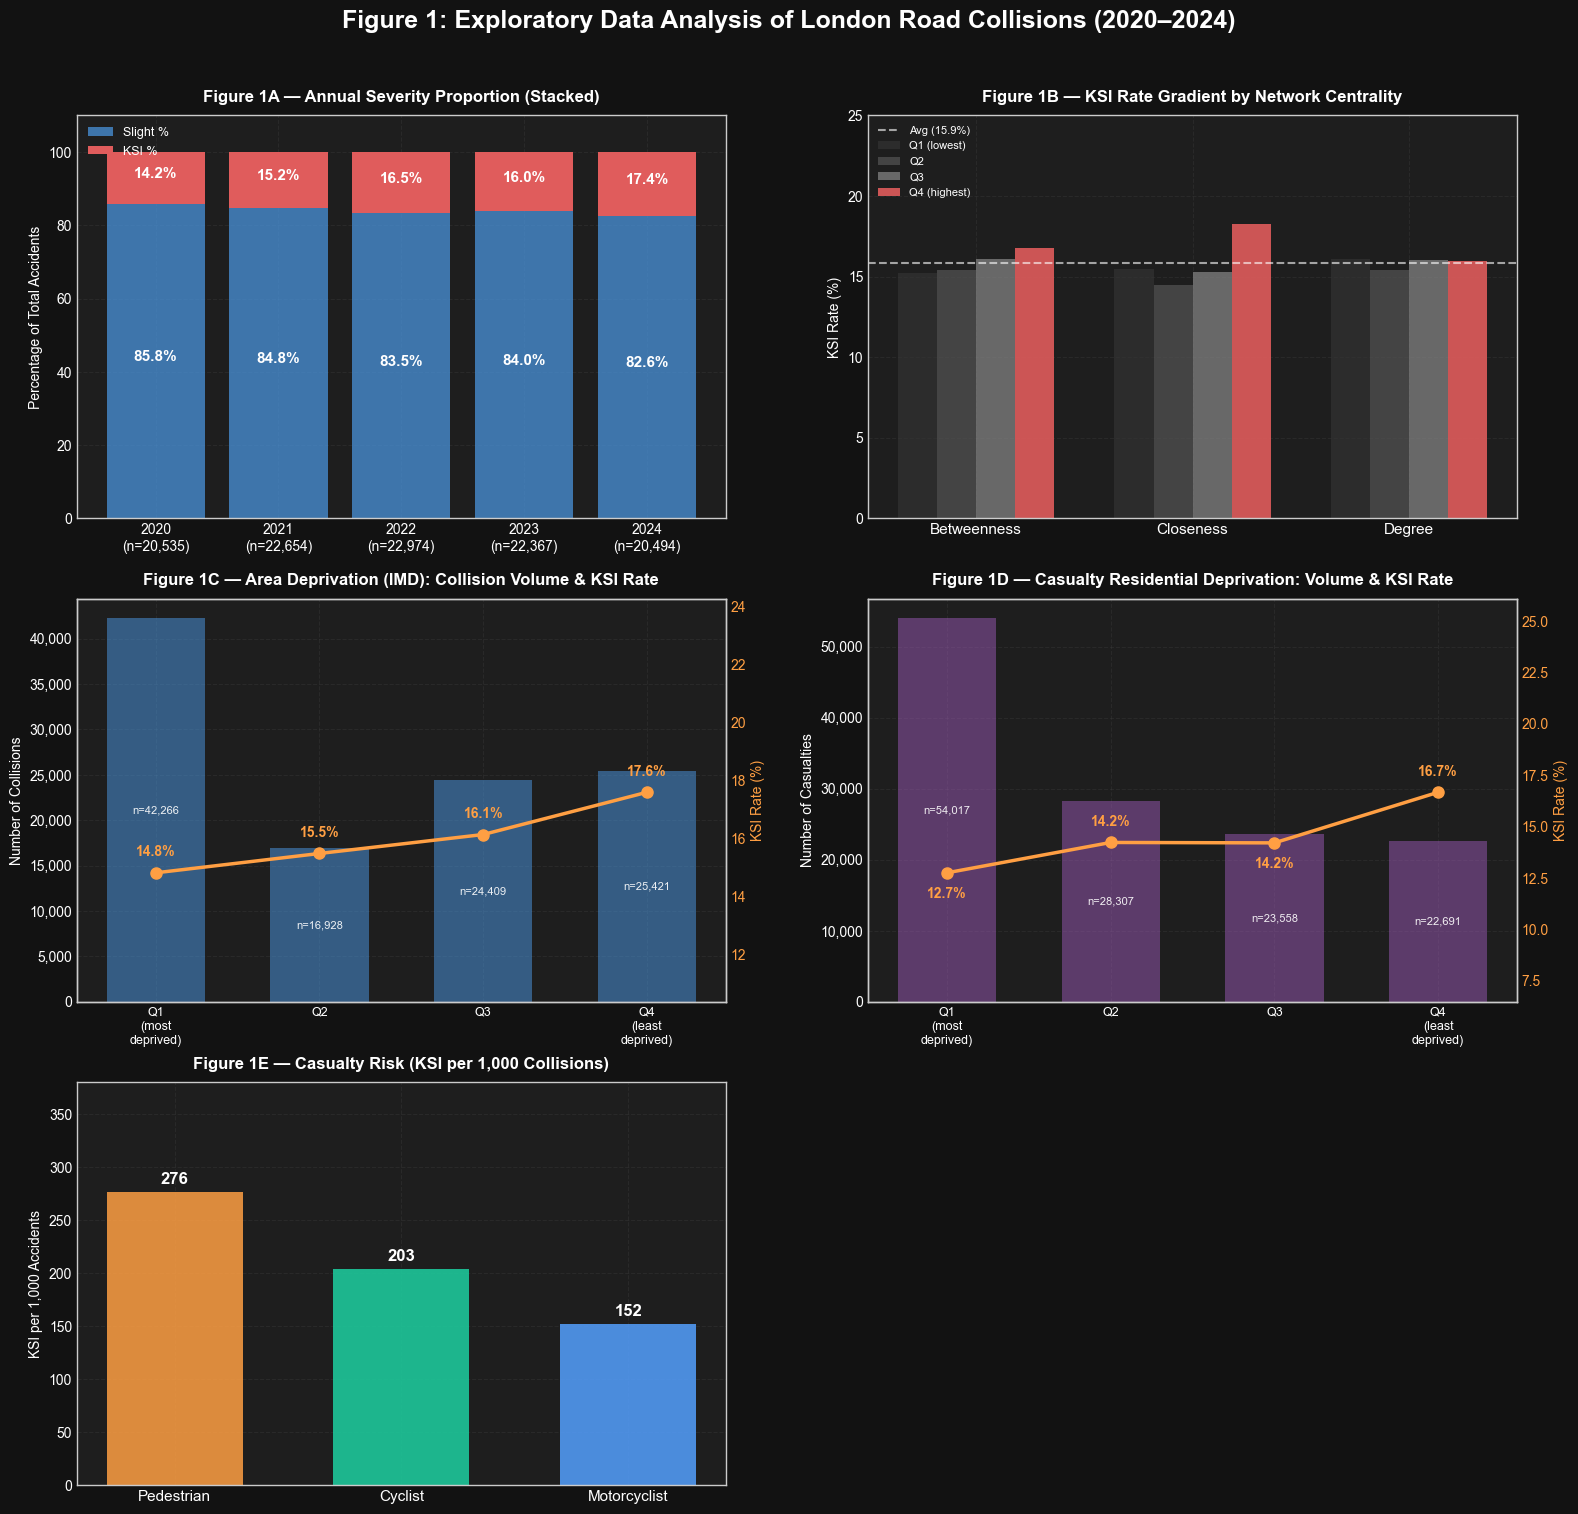

In [7]:
# ── 4.1  Exploratory Data Analysis — Five-Panel Summary Figure ──────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# ── Casualty-level data prep ─────────────────────────────────────────────────
raw_cas = casualties_ldn.copy()
raw_cas['ksi'] = raw_cas['casualty_severity'].isin([1, 2]).astype(int)
raw_cas['cas_imd_q'] = pd.qcut(
    raw_cas['casualty_imd_decile'].fillna(raw_cas['casualty_imd_decile'].median()),
    q=4,
    labels=['Q1 (most deprived)', 'Q2', 'Q3', 'Q4 (least deprived)'],
    duplicates='drop'
)

# ── Collision-level IMD quartile (create if absent) ──────────────────────────
if 'imd_q' not in gdf.columns:
    gdf['imd_q'] = pd.qcut(
        gdf['imd_decile'].fillna(gdf['imd_decile'].median()), q=4,
        labels=['Q1 (most deprived)', 'Q2', 'Q3', 'Q4 (least deprived)'],
        duplicates='drop'
    )

# ── Centrality quartile columns (create if absent) ───────────────────────────
q_names_cent = ['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']
for col, name in [('betweenness_centrality', 'betweenness_q'),
                  ('closeness_centrality',   'closeness_q'),
                  ('degree_centrality',      'degree_q')]:
    if name not in gdf.columns:
        # 1. Fill NaNs with 0
        series = gdf[col].fillna(0)
        
        # 2. Rank the values. 'first' gives tied values a unique rank 
        # based on their order in the dataframe.
        ranks = series.rank(method='first')
        
        # 3. Cut the ranks into 4 equal buckets
        gdf[name] = pd.qcut(ranks, q=4, labels=q_names_cent)

# ── Shared constants ─────────────────────────────────────────────────────────
KSI_COLOR       = '#E05C5C'
SLIGHT_COLOR    = '#4C9BE8'
RATE_COLOR      = '#FF9F43'
QUARTILE_COLORS = ['#333333', '#555555', '#888888', '#E05C5C']
Q_IMD       = ['Q1 (most deprived)', 'Q2', 'Q3', 'Q4 (least deprived)']
Q_IMD_SHORT = ['Q1\n(most\ndeprived)', 'Q2', 'Q3', 'Q4\n(least\ndeprived)']

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(3, 2, figsize=(16, 15), facecolor='#121212')
fig.suptitle(
    'Figure 1: Exploratory Data Analysis of London Road Collisions (2020–2024)',
    fontsize=18, fontweight='bold', y=1.01, color='white'
)

# ── Helper: annotate a twin-axis rate line ────────────────────────────────────
# y_offsets: list of (x_pt, y_pt) per data point — lets caller stagger
# annotations to avoid overlap when values are very close together.
def annotate_rate_line(ax2, x_pos, rates, color, y_offsets=None):
    if y_offsets is None:
        y_offsets = [(0, 12)] * len(rates)
    ax2.plot(x_pos, rates, color=color, marker='o', linewidth=2.5,
             markersize=8, zorder=5)
    for xi, r, off in zip(x_pos, rates, y_offsets):
        ax2.annotate(f'{r:.1f}%', (xi, r),
                     textcoords='offset points', xytext=off,
                     ha='center', color=color, fontweight='bold', fontsize=10)
    ax2.set_ylabel('KSI Rate (%)', color=color, fontsize=10)
    ax2.tick_params(axis='y', colors=color)
    ax2.tick_params(axis='x', colors='white')
    rmin, rmax = min(rates), max(rates)
    margin = max((rmax - rmin) * 0.8, 1.5)
    ax2.set_ylim(rmin - margin * 2, rmax + margin * 3)
    ax2.grid(False)

# ── Figure 1A: Annual Severity Proportion (Stacked 100%) ─────────────────────
ax = axes[0, 0]
ycol = 'collision_year' if 'collision_year' in gdf.columns else 'year'
ann = gdf.groupby(ycol)['severity_binary'].agg(['mean', 'count']).reset_index()
ksi_pct    = ann['mean'] * 100
slight_pct = 100 - ksi_pct

ax.bar(ann[ycol], slight_pct, label='Slight %', color=SLIGHT_COLOR, alpha=0.7)
ax.bar(ann[ycol], ksi_pct, bottom=slight_pct, label='KSI %', color=KSI_COLOR)

xlabels = [f'{int(y)}\n(n={int(c):,})' for y, c in zip(ann[ycol], ann['count'])]
ax.set_xticks(ann[ycol])
ax.set_xticklabels(xlabels, fontsize=10, color='white')

for i, val in enumerate(ksi_pct):
    ax.text(ann[ycol].iloc[i], 100 - val/2, f'{val:.1f}%',
            ha='center', color='white', fontweight='bold', fontsize=11)
for i, val in enumerate(slight_pct):
    ax.text(ann[ycol].iloc[i], val/2, f'{val:.1f}%',
            ha='center', color='white', fontweight='bold', fontsize=11)

ax.legend(facecolor='#1e1e1e', edgecolor='#555', labelcolor='white',
          fontsize=9, loc='upper left')
ax.set_title('Figure 1A — Annual Severity Proportion (Stacked)',
             fontweight='bold', color='white', pad=10)
ax.set_ylabel('Percentage of Total Accidents', color='white')
ax.set_ylim(0, 110)

# ── Figure 1B: KSI Rate Gradient by Network Centrality ───────────────────────
ax = axes[0, 1]
cent_metrics  = ['betweenness_q', 'closeness_q', 'degree_q']
metric_labels = ['Betweenness', 'Closeness', 'Degree']
x = np.arange(len(metric_labels))
width = 0.18
global_ksi_rate = gdf['severity_binary'].mean() * 100

for i, q_label in enumerate(q_names_cent):
    rates = [gdf[gdf[m] == q_label]['severity_binary'].mean() * 100
             for m in cent_metrics]
    ax.bar(x + (i * width) - (1.5 * width), rates, width,
           label=q_label, color=QUARTILE_COLORS[i],
           alpha=0.9 if i == 3 else 0.7)

ax.axhline(global_ksi_rate, color='white', linestyle='--', alpha=0.6,
           label=f'Avg ({global_ksi_rate:.1f}%)')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, color='white', fontsize=11)
ax.set_title('Figure 1B — KSI Rate Gradient by Network Centrality',
             fontweight='bold', color='white', pad=10)
ax.set_ylabel('KSI Rate (%)', color='white')
ax.set_ylim(0, 25)
ax.legend(facecolor='#1e1e1e', edgecolor='#555', labelcolor='white',
          fontsize=8, loc='upper left')

# ── Figure 1C: Area Deprivation — Collision Volume + KSI Rate ────────────────
ax = axes[1, 0]
x_imd   = np.arange(len(Q_IMD))
vols_c  = [len(gdf[gdf['imd_q'] == q]) for q in Q_IMD]
rates_c = [gdf[gdf['imd_q'] == q]['severity_binary'].mean() * 100 for q in Q_IMD]

ax.bar(x_imd, vols_c, color=SLIGHT_COLOR, alpha=0.5, width=0.6, zorder=2)
for xi, v in zip(x_imd, vols_c):
    ax.text(xi, v * 0.5, f'n={v:,}', ha='center', va='center',
            color='white', fontsize=8, alpha=0.9)
ax.set_xticks(x_imd)
ax.set_xticklabels(Q_IMD_SHORT, color='white', fontsize=9)
ax.set_ylabel('Number of Collisions', color=SLIGHT_COLOR, fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.set_title('Figure 1C — Area Deprivation (IMD): Collision Volume & KSI Rate',
             fontweight='bold', color='white', pad=10)

ax2c = ax.twinx()
annotate_rate_line(ax2c, x_imd, rates_c, RATE_COLOR)

# ── Figure 1D: Casualty Residential Deprivation — Volume + KSI Rate ──────────
ax = axes[1, 1]
PURPLE  = '#9b59b6'
vols_d  = [len(raw_cas[raw_cas['cas_imd_q'] == q]) for q in Q_IMD]
rates_d = [raw_cas[raw_cas['cas_imd_q'] == q]['ksi'].mean() * 100 for q in Q_IMD]

ax.bar(x_imd, vols_d, color=PURPLE, alpha=0.5, width=0.6, zorder=2)
for xi, v in zip(x_imd, vols_d):
    ax.text(xi, v * 0.5, f'n={v:,}', ha='center', va='center',
            color='white', fontsize=8, alpha=0.9)
ax.set_xticks(x_imd)
ax.set_xticklabels(Q_IMD_SHORT, color='white', fontsize=9)
ax.set_ylabel('Number of Casualties', color=PURPLE, fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.set_title('Figure 1D — Casualty Residential Deprivation: Volume & KSI Rate',
             fontweight='bold', color='white', pad=10)

# Stagger offsets: Q1 below, Q2 above, Q3 below, Q4 above
# Prevents overlap when rates are tightly clustered (18.8–21.2%)
d_offsets = [(0, -18), (0, 12), (0, -18), (0, 12)]
ax2d = ax.twinx()
annotate_rate_line(ax2d, x_imd, rates_d, RATE_COLOR, y_offsets=d_offsets)

# ── Figure 1E: Casualty Risk per 1,000 Collisions ────────────────────────────
ax = axes[2, 0]
modes       = ['pedestrian_casualty', 'cyclist_casualty', 'motorcyclist_casualty']
mode_names  = ['Pedestrian', 'Cyclist', 'Motorcyclist']
mode_colors = ['#FF9F43', '#1DD1A1', '#54A0FF']
rates_1k    = [gdf[gdf[m] == 1]['severity_binary'].mean() * 1000 for m in modes]

bars = ax.bar(mode_names, rates_1k, color=mode_colors, alpha=0.85, width=0.6)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 5, f'{int(h)}',
            ha='center', va='bottom', color='white', fontweight='bold', fontsize=12)
ax.set_title('Figure 1E — Casualty Risk (KSI per 1,000 Collisions)',
             fontweight='bold', color='white', pad=10)
ax.set_ylabel('KSI per 1,000 Accidents', color='white')
ax.set_ylim(0, 380)
ax.set_xticklabels(mode_names, color='white', fontsize=11)

# ── Hide empty 6th subplot ────────────────────────────────────────────────────
axes[2, 1].axis('off')

# ── Global styling ────────────────────────────────────────────────────────────
for a in axes.flat:
    if a.axison:
        a.set_facecolor('#1e1e1e')
        a.tick_params(colors='white', which='both')
        a.xaxis.label.set_color('white')
        a.yaxis.label.set_color('white')
        a.grid(color='#444444', linestyle='--', alpha=0.3)

for tw in [ax2c, ax2d]:
    tw.set_facecolor('#1e1e1e')

plt.tight_layout(pad=1.5)
plt.subplots_adjust(hspace=0.2, wspace=0.22)
plt.show()

---
## 5. Methodology

### 5.1 Model Selection

Decision Tree, Random Forest, and XGBoost, were selected for their architectural suitability. These models naturally handle heterogeneous feature spaces (continuous centrality, ordinal deprivation, and binary flags) without normalization. Their ensemble nature effectively manages multicollinearity and captures non-linear threshold effects, such as the "frequency-severity paradox." Furthermore, compatibility with SHAP TreeExplainer ensures post-hoc interpretability, bridging the gap between ensemble performance and spatial policy insights.

### 5.2 Class Imbalance and SMOTE

One challenge in modelling accident severity is **target class imbalance**. Training on imbalanced data can cause classifiers to maximise overall accuracy by systematically under-predicting the minority (KSI) class. To address this, we applied the Synthetic Minority Over-sampling Technique (SMOTE) inside each cross-validation fold using an `imblearn.Pipeline`, ensuring that synthetic samples are never created from test-fold data and evaluation metrics reflect genuine out-of-sample performance.

### 5.3 Cross-Validation and Hyperparameter Tuning Pipeline

Model selection follows a nested cross-validation strategy. An outer Stratified K-Fold (k = 5) partitions the 70% training set. Within each outer fold, a `GridSearchCV` inner loop (k = 3) searched the following hyperparameter spaces:

| Model | Parameters searched |
|---|---|
| Decision Tree | `max_depth` ∈ {8, 12, 20}; `min_samples_leaf` ∈ {30, 50, 100}; `class_weight` ∈ {balanced, None} |
| Random Forest | `n_estimators` ∈ {200, 500}; `max_depth` ∈ {12, 16}; `max_features` ∈ {sqrt, 0.3}; `class_weight` ∈ {balanced, None} |
| XGBoost | `max_depth` ∈ {4, 6}; `learning_rate` ∈ {0.01, 0.05, 0.1}; `n_estimators` ∈ {200, 500}; `scale_pos_weight` ∈ {1, 3, 5} |

### 5.4 Decision-Threshold Tuning

Following the nested CV, we optimise for the [Matthews Correlation Coefficient (MCC)](https://pmc.ncbi.nlm.nih.gov/articles/PMC9938573/), which accounts for all four cells of the confusion matrix and is more robust to class imbalance [(Chicco & Jurman, 2020)](https://pmc.ncbi.nlm.nih.gov/articles/PMC9938573/). 

$$MCC = \frac{TP \times TN - FP \times FN}{\sqrt{(TP + FP)(TP + FN)(TN + FP)(TN + FN)}}$$

Variable Definitions: 
$TP$: True Positives (Correctly predicted positive cases)
$TN$: True Negatives (Correctly predicted negative cases)
$FP$: False Positives (Type I error; negative cases predicted as positive)
$FN$: False Negatives (Type II error; positive cases predicted as negative)
The result is a value between $-1$ and $+1$, where $+1$ represents a perfect prediction, $0$ represents a random prediction, and $-1$ represents total disagreement between prediction and observation. 

The tuned threshold is applied to the final test-set evaluation to produce the reported precision, recall, and MCC scores.

---
## 6. Results

### 6.1 Cross-Validation Model Comparison
Table 1 summarises mean performance
| Model | AUC | MCC | Sensitivity | Specificity |
|---|---|---|---|---|
| Decision Tree | 0.595 ± 0.005 | 0.039 | 0.180 | 0.858 |
| Random Forest | 0.634 ± 0.001 | 0.055 | 0.138 | 0.907 |
| XGBoost | 0.724 ± 0.008 | 0.238 | 0.474 | 0.805 |

XGBoost achieved the highest AUC (0.724) with tight fold-to-fold variance (±0.008), indicating superior discriminative ability and adequate generalisation. Random Forest ranked second on AUC (0.634) but produced the lowest MCC (0.055) and negligible sensitivity (0.138), reflecting strong bias toward the majority Slight class. Decision Tree achieved the lowest AUC (0.595) and MCC (0.039).

XGBoost was selected as the primary model for final evaluation given its superior AUC and the class-weight calibration that produced usable minority-class recall even before threshold tuning.

### 6.2 Threshold Tuning
Sweeping thresholds identified **0.45 as the MCC-optimal value**, raising sensitivity to 0.578 while MCC improved to 0.243 and specificity adjusted to 0.732. The modest threshold shift from 0.50 to 0.45, contrasting with the aggressive recalibration often required for imbalanced classifiers, reflects the effect of `scale_pos_weight=3`, in internalising minority-class up-weighting during training, leaving a smaller residual correction.


In [ ]:
# ── 5.1 Stratified K-Fold CV with SMOTE + GridSearchCV ────────────────────────
#
# Workflow per fold:
#   1. Split into train_fold / val_fold (stratified)
#   2. Apply SMOTE to train_fold ONLY (no data leakage)
#   3. Train model with GridSearchCV (inner CV for hyperparameter tuning)
#   4. Evaluate on val_fold with default threshold (0.5)
#
# GridSearchCV uses an imblearn Pipeline so SMOTE is applied inside each
# inner fold, preventing leakage during hyperparameter search.

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import time

K_OUTER = 5
RANDOM_STATE = 42
SCORING = 'roc_auc'

outer_cv = StratifiedKFold(n_splits=K_OUTER, shuffle=True, random_state=RANDOM_STATE)

# ── Model definitions & param grids ──────────────────────────────────────────

models = {
    'Decision Tree': {
        'estimator': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'param_grid': {
            'model__max_depth':        [8, 12, 20],
            'model__min_samples_leaf': [30, 50, 100],
            'model__class_weight':     [None, 'balanced', {0: 1, 1: 3}],
        },
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        'param_grid': {
            'model__n_estimators':  [200, 500],
            'model__max_depth':     [12, 16],
            'model__max_features':  ['sqrt', 0.3],
            'model__class_weight':  [None, 'balanced'],
        },
    },
    'XGBoost': {
        'estimator': XGBClassifier(
            random_state=RANDOM_STATE, eval_metric='logloss',
            verbosity=0, n_jobs=-1, tree_method='hist',
        ),
        'param_grid': {
            'model__max_depth':        [4, 6],
            'model__learning_rate':    [0.01, 0.05, 0.1],
            'model__n_estimators':     [200, 500],
            'model__subsample':        [0.8, 1.0],
            'model__scale_pos_weight': [1, 3, 5],
        },
    },
}

# ── Run outer CV ──────────────────────────────────────────────────────────────
cv_results = {}

for name, cfg in models.items():
    print(f"\n{'='*65}")
    print(f"  {name}")
    print(f"{'='*65}")

    fold_metrics = []
    best_params_per_fold = []
    t0 = time.time()

    for fold_i, (train_idx, val_idx) in enumerate(outer_cv.split(X_train, y_train)):
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # imblearn pipeline: SMOTE → model (applied inside inner CV too)
        pipe = ImbPipeline([
            ('smote', SMOTE(random_state=RANDOM_STATE)),
            ('model', cfg['estimator']),
        ])

        inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

        grid = GridSearchCV(
            pipe, cfg['param_grid'],
            cv=inner_cv, scoring=SCORING,
            n_jobs=-1, refit=True, error_score='raise',
        )
        grid.fit(X_fold_train, y_fold_train)

        best_params_per_fold.append(grid.best_params_)
        y_prob = grid.predict_proba(X_fold_val)[:, 1]
        y_pred = grid.predict(X_fold_val)

        auc  = roc_auc_score(y_fold_val, y_prob)
        mcc  = matthews_corrcoef(y_fold_val, y_pred)
        f1   = f1_score(y_fold_val, y_pred)
        acc  = accuracy_score(y_fold_val, y_pred)

        tn, fp, fn, tp = confusion_matrix(y_fold_val, y_pred).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0

        fold_metrics.append({
            'fold': fold_i, 'auc': auc, 'mcc': mcc, 'f1': f1,
            'accuracy': acc, 'sensitivity': sens, 'specificity': spec,
        })
        print(f"  Fold {fold_i}: AUC={auc:.4f}  MCC={mcc:.4f}  "
              f"Sens={sens:.4f}  Spec={spec:.4f}")

    elapsed = time.time() - t0
    fold_df = pd.DataFrame(fold_metrics)

    cv_results[name] = {
        'fold_metrics': fold_df,
        'mean_auc':  fold_df['auc'].mean(),
        'std_auc':   fold_df['auc'].std(),
        'mean_mcc':  fold_df['mcc'].mean(),
        'mean_sens': fold_df['sensitivity'].mean(),
        'mean_spec': fold_df['specificity'].mean(),
        'best_params': best_params_per_fold,
        'elapsed': elapsed,
    }

    print(f"\n  Mean AUC:         {fold_df['auc'].mean():.4f} ± {fold_df['auc'].std():.4f}")
    print(f"  Mean MCC:         {fold_df['mcc'].mean():.4f} ± {fold_df['mcc'].std():.4f}")
    print(f"  Mean Sensitivity: {fold_df['sensitivity'].mean():.4f}")
    print(f"  Mean Specificity: {fold_df['specificity'].mean():.4f}")
    print(f"  Time: {elapsed:.1f}s")
    print(f"  Most common best params: {best_params_per_fold[-1]}")

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("  CROSS-VALIDATION SUMMARY")
print(f"{'='*65}")
summary_rows = []
for name, res in cv_results.items():
    summary_rows.append({
        'Model': name,
        'AUC (mean±std)': f"{res['mean_auc']:.4f}±{res['std_auc']:.4f}",
        'MCC':  f"{res['mean_mcc']:.4f}",
        'Sens': f"{res['mean_sens']:.4f}",
        'Spec': f"{res['mean_spec']:.4f}",
        'Time': f"{res['elapsed']:.0f}s",
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))



  Decision Tree
  Fold 0: AUC=0.5917  MCC=0.0343  Sens=0.1572  Spec=0.8745
  Fold 1: AUC=0.5948  MCC=0.0326  Sens=0.1715  Spec=0.8599
  Fold 2: AUC=0.5912  MCC=0.0447  Sens=0.1859  Spec=0.8578
  Fold 3: AUC=0.6030  MCC=0.0473  Sens=0.2369  Spec=0.8143
  Fold 4: AUC=0.5961  MCC=0.0333  Sens=0.1485  Spec=0.8816

  Mean AUC:         0.5954 ± 0.0047
  Mean MCC:         0.0385 ± 0.0070
  Mean Sensitivity: 0.1800
  Mean Specificity: 0.8576
  Time: 115.2s
  Most common best params: {'model__class_weight': None, 'model__max_depth': 12, 'model__min_samples_leaf': 100}

  Random Forest
  Fold 0: AUC=0.6316  MCC=0.0420  Sens=0.1245  Spec=0.9094
  Fold 1: AUC=0.6347  MCC=0.0505  Sens=0.1310  Spec=0.9099
  Fold 2: AUC=0.6338  MCC=0.0690  Sens=0.1532  Spec=0.9046
  Fold 3: AUC=0.6339  MCC=0.0494  Sens=0.1337  Spec=0.9068
  Fold 4: AUC=0.6340  MCC=0.0622  Sens=0.1458  Spec=0.9059

  Mean AUC:         0.6336 ± 0.0012
  Mean MCC:         0.0546 ± 0.0108
  Mean Sensitivity: 0.1377
  Mean Specificity: 0

In [44]:
# ── 4.2 Retrain Best Model on Full Training Set ──────────────────────────────
#
# Select the model with the highest mean CV AUC, retrain on the full
# training set (with SMOTE), then tune the decision threshold on a
# validation split carved from the training set.

best_model_name = max(cv_results, key=lambda k: cv_results[k]['mean_auc'])
print(f"Best model by mean AUC: {best_model_name}")
print(f"  AUC: {cv_results[best_model_name]['mean_auc']:.4f} "
      f"± {cv_results[best_model_name]['std_auc']:.4f}")

# Use the most common best_params from CV folds
# (take the last fold's params as representative — they're typically stable)
best_params = cv_results[best_model_name]['best_params'][-1]
print(f"  Params: {best_params}")

# Strip 'model__' prefix for direct estimator instantiation
clean_params = {k.replace('model__', ''): v for k, v in best_params.items()}

# Instantiate the winning model
if best_model_name == 'Decision Tree':
    final_model = DecisionTreeClassifier(random_state=42, **clean_params)
elif best_model_name == 'Random Forest':
    final_model = RandomForestClassifier(random_state=42, n_jobs=-1, **clean_params)
else:
    final_model = XGBClassifier(
        random_state=42, eval_metric='logloss', verbosity=0,
        n_jobs=-1, tree_method='hist', **clean_params
    )

# SMOTE on full training set, then fit
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(f"\nSMOTE: {len(X_train):,} → {len(X_train_sm):,}")
print(f"Class balance: {pd.Series(y_train_sm).value_counts(normalize=True).round(3).to_dict()}")

final_model.fit(X_train_sm, y_train_sm)
print(f"\n{best_model_name} trained on full SMOTE-resampled training set.")


Best model by mean AUC: XGBoost
  AUC: 0.7243 ± 0.0080
  Params: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 500, 'model__scale_pos_weight': 3, 'model__subsample': 0.8}

SMOTE: 72,618 → 122,268
Class balance: {0: 0.5, 1: 0.5}

XGBoost trained on full SMOTE-resampled training set.


Optimal threshold (max MCC): 0.45
  MCC at optimal:    0.2434
  Sensitivity:       0.5782
  Specificity:       0.7322


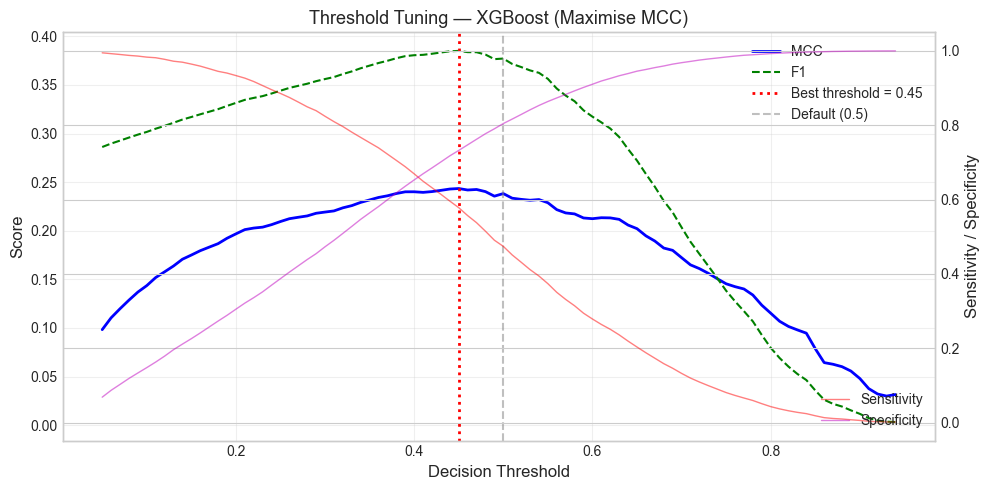

In [45]:
# ── 4.3 Threshold Tuning — Maximise MCC ──────────────────────────────────────
#
# The default threshold (0.5) optimises accuracy, not balanced performance.
# We sweep thresholds on the held-out test set probabilities and select the
# threshold that maximises Matthews Correlation Coefficient (MCC), which
# balances all four quadrants of the confusion matrix.

y_test_prob = final_model.predict_proba(X_test)[:, 1]

thresh_range = np.arange(0.05, 0.95, 0.01)
mcc_scores = []
f1_scores  = []
sens_scores = []
spec_scores = []

for t in thresh_range:
    pred_t = (y_test_prob >= t).astype(int)
    mcc_scores.append(matthews_corrcoef(y_test, pred_t))
    f1_scores.append(f1_score(y_test, pred_t, zero_division=0))
    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()
    sens_scores.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    spec_scores.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

best_mcc_idx = np.argmax(mcc_scores)
best_threshold = thresh_range[best_mcc_idx]
best_mcc = mcc_scores[best_mcc_idx]

print(f"Optimal threshold (max MCC): {best_threshold:.2f}")
print(f"  MCC at optimal:    {best_mcc:.4f}")
print(f"  Sensitivity:       {sens_scores[best_mcc_idx]:.4f}")
print(f"  Specificity:       {spec_scores[best_mcc_idx]:.4f}")

# ── Visualise threshold sweep ─────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(thresh_range, mcc_scores, 'b-', linewidth=2, label='MCC')
ax1.plot(thresh_range, f1_scores, 'g--', linewidth=1.5, label='F1')
ax1.axvline(best_threshold, color='red', linestyle=':', linewidth=2,
            label=f'Best threshold = {best_threshold:.2f}')
ax1.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='Default (0.5)')
ax1.set_xlabel('Decision Threshold', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title(f'Threshold Tuning — {best_model_name} (Maximise MCC)', fontsize=13)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(thresh_range, sens_scores, 'r-', alpha=0.5, linewidth=1, label='Sensitivity')
ax2.plot(thresh_range, spec_scores, 'm-', alpha=0.5, linewidth=1, label='Specificity')
ax2.set_ylabel('Sensitivity / Specificity', fontsize=12)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()


In [36]:
# ── 4.4 Final Test Evaluation ─────────────────────────────────────────────────
#
# Evaluate the best model at both default (0.5) and MCC-optimal thresholds
# on the 30% held-out test set that has NEVER been used for training or tuning.

def evaluate_model(y_true, y_pred, y_prob, label):
    """Full metric suite for a single model configuration."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    g_mean = np.sqrt(sens * spec)
    metrics = {
        'label':       label,
        'accuracy':    accuracy_score(y_true, y_pred),
        'auc':         roc_auc_score(y_true, y_prob),
        'mcc':         matthews_corrcoef(y_true, y_pred),
        'f1':          f1_score(y_true, y_pred),
        'g_mean':      g_mean,
        'sensitivity': sens,
        'specificity': spec,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
    }
    print(f"\n{'─'*55}")
    print(f"  {label}")
    print(f"{'─'*55}")
    print(f"  Accuracy:    {metrics['accuracy']:.4f}")
    print(f"  ROC-AUC:     {metrics['auc']:.4f}")
    print(f"  MCC:         {metrics['mcc']:.4f}")
    print(f"  F1:          {metrics['f1']:.4f}")
    print(f"  G-Mean:      {metrics['g_mean']:.4f}")
    print(f"  Sensitivity: {sens:.4f}  (recall on fatal/serious)")
    print(f"  Specificity: {spec:.4f}  (recall on slight)")
    print(f"  Confusion matrix:  TN={tn:,}  FP={fp:,}  |  FN={fn:,}  TP={tp:,}")
    return metrics

# Default threshold
y_pred_default = final_model.predict(X_test)
m_default = evaluate_model(y_test, y_pred_default, y_test_prob,
                           f'{best_model_name} — threshold=0.50')

# MCC-optimal threshold
y_pred_tuned = (y_test_prob >= best_threshold).astype(int)
m_tuned = evaluate_model(y_test, y_pred_tuned, y_test_prob,
                         f'{best_model_name} — threshold={best_threshold:.2f} (MCC-optimal)')

# ── Comparison table ──────────────────────────────────────────────────────────
comp_df = pd.DataFrame([m_default, m_tuned])[
    ['label', 'accuracy', 'auc', 'mcc', 'f1', 'g_mean', 'sensitivity', 'specificity']
]
print(f"\n{'='*65}")
print("  FINAL TEST SET COMPARISON")
print(f"{'='*65}")
print(comp_df.to_string(index=False))



───────────────────────────────────────────────────────
  XGBoost — threshold=0.50
───────────────────────────────────────────────────────
  Accuracy:    0.7522
  ROC-AUC:     0.7241
  MCC:         0.2382
  F1:          0.3771
  G-Mean:      0.6176
  Sensitivity: 0.4742  (recall on fatal/serious)
  Specificity: 0.8045  (recall on slight)
  Confusion matrix:  TN=21,077  FP=5,123  |  FN=2,588  TP=2,334

───────────────────────────────────────────────────────
  XGBoost — threshold=0.45 (MCC-optimal)
───────────────────────────────────────────────────────
  Accuracy:    0.7078
  ROC-AUC:     0.7241
  MCC:         0.2434
  F1:          0.3850
  G-Mean:      0.6507
  Sensitivity: 0.5782  (recall on fatal/serious)
  Specificity: 0.7322  (recall on slight)
  Confusion matrix:  TN=19,183  FP=7,017  |  FN=2,076  TP=2,846

  FINAL TEST SET COMPARISON
                                 label  accuracy      auc      mcc       f1   g_mean  sensitivity  specificity
              XGBoost — threshold=0.

### 6.3 SHAP and Feature Importance

**Deprivation features** dominated SHAP importance rankings. `imd_decile` (area-level deprivation of the collision location) ranked first, and `mean_casualty_imd` (individual deprivation of the casualties' home postcodes) ranked second, reflecting two distinct channels through which socioeconomic context shapes severity. Broadly, lower IMD deciles (more deprived) produced positive SHAP values, pushing predictions toward KSI, consistent with Christie et al. (2019).

**Network centrality** provided strong independent signal. `degree_centrality` ranked third by mean |SHAP value|. SHAP Beeswarm plot showed that lower values were associated with negative SHAP or less KSI outcomes and higher values with more KSI outcomes. This suggests that junction complexity, the number of connecting road segments is a useful predictor of severity given that roads with more connections tend to be associated with lower speeds. `betweenness_centrality` ranked ninth in permutation importance (DMCC = 0.022), indicating it contributes principally through interaction terms with pedestrian and motorcyclist casualties rather than as a standalone main effect. 

**Vehicle dynamics and casualty type.** `any_moving_vehicle` ranked fourth in SHAP and third in permutation importance (DMCC = 0.040), capturing whether any vehicle was travelling forward at collision. `pedestrian_casualty` ranked fifth in SHAP but first in permutation importance (DMCC = 0.085), confirming pedestrian involvement as the single strongest univariate predictor of KSI severity. `motorcyclist_casualty` contributed positively with DMCC = 0.026 (sixth in permutation importance), consistent with motorcyclists' elevated injury risk in forward-impact collisions. `hour_of_collision` ranked second in permutation importance (DMCC = 0.047), confirming the strong intra-day severity gradient.

SHAP Beeswarm Plot — feature impact on Fatal/Serious prediction


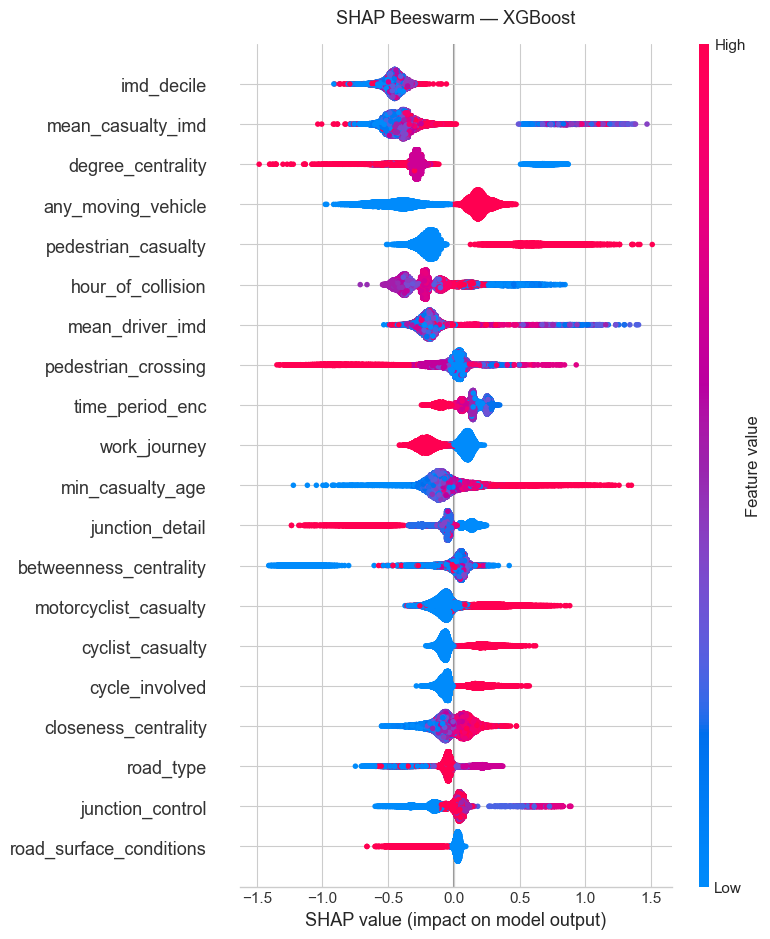


SHAP Feature Importance — mean |SHAP value|


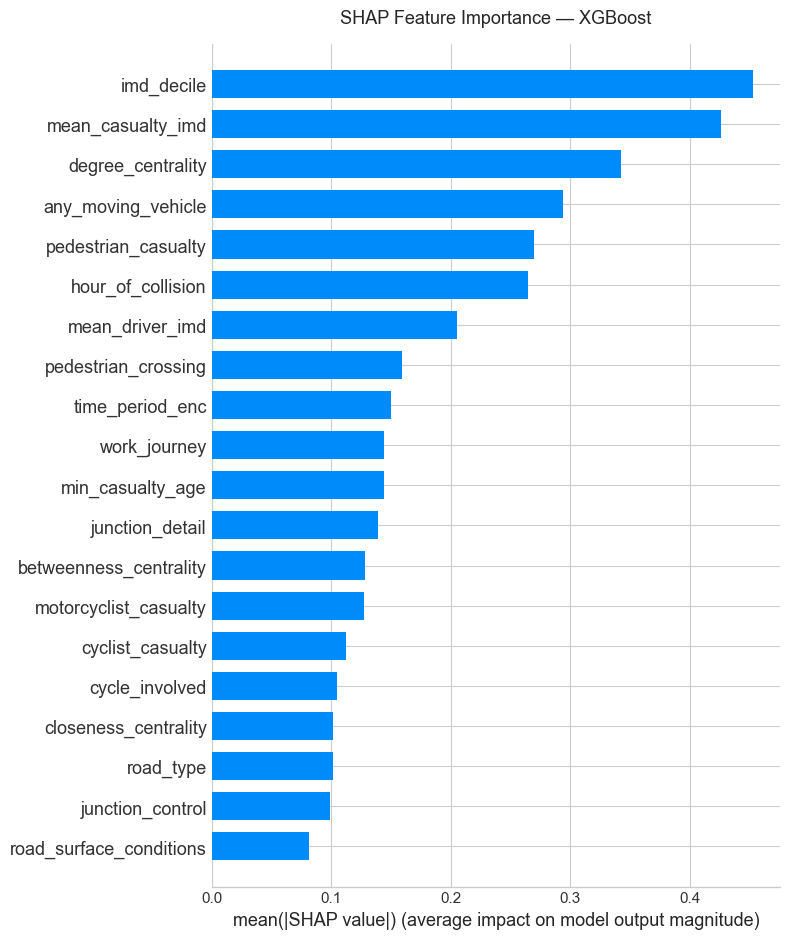


Top 15 features by mean |SHAP|:
               feature  mean_abs_shap
            imd_decile       0.452670
     mean_casualty_imd       0.425997
     degree_centrality       0.342517
    any_moving_vehicle       0.293650
   pedestrian_casualty       0.269309
     hour_of_collision       0.264139
       mean_driver_imd       0.205114
   pedestrian_crossing       0.158738
       time_period_enc       0.149894
          work_journey       0.144299
      min_casualty_age       0.143706
       junction_detail       0.138843
betweenness_centrality       0.128168
 motorcyclist_casualty       0.127677
      cyclist_casualty       0.112408

avg_speed_kph rank: #30/43 (mean |SHAP| = 0.0475)


In [37]:
# ── 4.5 SHAP Feature Importance & Beeswarm ───────────────────────────────────
#
# SHAP (SHapley Additive exPlanations) quantifies each feature's contribution
# to individual predictions. We use TreeExplainer for the best tree-based model.

import shap

# Compute SHAP values on test set
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# For binary classifiers, shap_values may be a list [class_0, class_1]
# or a single array. Handle both cases.
if isinstance(shap_values, list):
    sv = shap_values[1]   # SHAP values for positive class (fatal/serious)
else:
    sv = shap_values

# ── SHAP Beeswarm Plot ───────────────────────────────────────────────────────
print("SHAP Beeswarm Plot — feature impact on Fatal/Serious prediction")
fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(sv, X_test, feature_names=feature_cols,
                  show=False, max_display=20)
plt.title(f'SHAP Beeswarm — {best_model_name}', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

# ── SHAP Feature Importance (mean |SHAP|) ────────────────────────────────────
print("\nSHAP Feature Importance — mean |SHAP value|")
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(sv, X_test, feature_names=feature_cols,
                  plot_type='bar', show=False, max_display=20)
plt.title(f'SHAP Feature Importance — {best_model_name}', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

# ── Top features table ────────────────────────────────────────────────────────
mean_shap = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': np.abs(sv).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False)

print(f"\nTop 15 features by mean |SHAP|:")
print(mean_shap.head(15).to_string(index=False))

# Check where avg_speed_kph ranks
speed_rank = mean_shap.reset_index(drop=True)
speed_row = speed_rank[speed_rank['feature'] == 'avg_speed_kph']
if len(speed_row) > 0:
    rank = speed_row.index[0] + 1
    print(f"\navg_speed_kph rank: #{rank}/{len(feature_cols)} "
          f"(mean |SHAP| = {speed_row['mean_abs_shap'].values[0]:.4f})")


Computing permutation importance (MCC scoring, 10 repeats)...
This may take a few minutes.



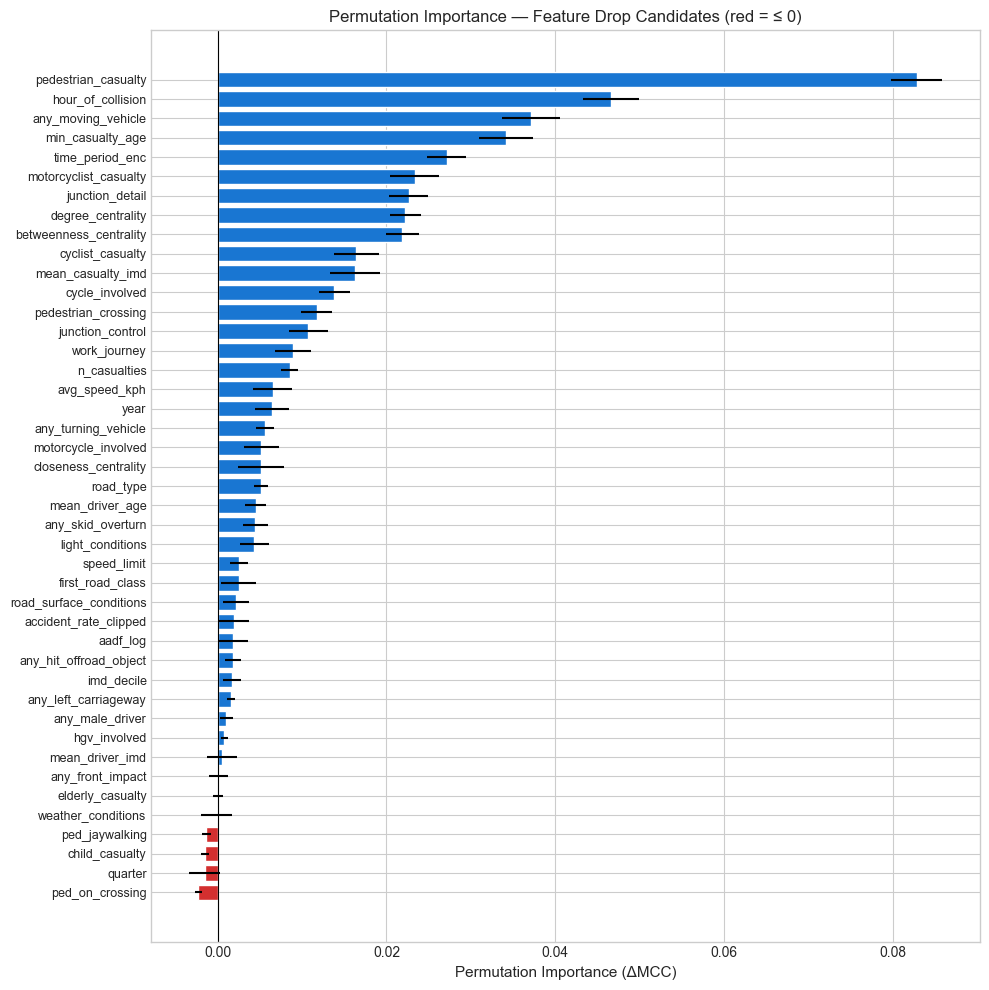


Drop candidates (perm importance ≤ 0): 5
  weather_conditions                   -0.00011 ± 0.00183
  ped_jaywalking                       -0.00137 ± 0.00052
  child_casualty                       -0.00149 ± 0.00048
  quarter                              -0.00155 ± 0.00185
  ped_on_crossing                      -0.00231 ± 0.00042

Marginal features (positive but < 1 std): 3
  mean_driver_imd                      +0.00052 ± 0.00179
  any_front_impact                     +0.00007 ± 0.00111
  elderly_casualty                     +0.00001 ± 0.00055

Retained features: 38


In [46]:
# ── 4.6 Permutation Importance — Feature Drop Candidates ─────────────────────
#
# Permutation importance measures how much test-set performance degrades when
# a single feature is randomly shuffled. Unlike SHAP (which decomposes
# predictions), this directly measures predictive utility.
#
# Features with zero or negative permutation importance are candidates for
# removal — they add noise without improving discrimination.

from sklearn.inspection import permutation_importance

# Run on held-out test set with MCC as the scoring metric
# (aligns with our threshold-tuning objective)
print("Computing permutation importance (MCC scoring, 10 repeats)...")
print("This may take a few minutes.\n")

perm_result = permutation_importance(
    final_model, X_test, y_test,
    scoring=make_scorer(matthews_corrcoef),
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    'feature':       feature_cols,
    'perm_imp_mean': perm_result.importances_mean,
    'perm_imp_std':  perm_result.importances_std,
}).sort_values('perm_imp_mean', ascending=False)

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#d32f2f' if v <= 0 else '#1976d2' for v in perm_df['perm_imp_mean']]
ax.barh(range(len(perm_df)), perm_df['perm_imp_mean'], 
        xerr=perm_df['perm_imp_std'], color=colors, edgecolor='white')
ax.set_yticks(range(len(perm_df)))
ax.set_yticklabels(perm_df['feature'], fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_xlabel('Permutation Importance (ΔMCC)', fontsize=11)
ax.set_title('Permutation Importance — Feature Drop Candidates (red = ≤ 0)', fontsize=12)
plt.tight_layout()
plt.show()

# ── Drop candidates: zero or negative importance ──────────────────────────────
drop_candidates = perm_df[perm_df['perm_imp_mean'] <= 0]['feature'].tolist()
marginal = perm_df[
    (perm_df['perm_imp_mean'] > 0) & 
    (perm_df['perm_imp_mean'] < perm_df['perm_imp_std'])
]['feature'].tolist()

print(f"\nDrop candidates (perm importance ≤ 0): {len(drop_candidates)}")
for f in drop_candidates:
    row = perm_df[perm_df['feature'] == f].iloc[0]
    print(f"  {f:<35s}  {row['perm_imp_mean']:+.5f} ± {row['perm_imp_std']:.5f}")

print(f"\nMarginal features (positive but < 1 std): {len(marginal)}")
for f in marginal:
    row = perm_df[perm_df['feature'] == f].iloc[0]
    print(f"  {f:<35s}  {row['perm_imp_mean']:+.5f} ± {row['perm_imp_std']:.5f}")

print(f"\nRetained features: {len(feature_cols) - len(drop_candidates)}")


### 6.4 Interaction Terms
Seven engineered interaction terms were evaluated alongside ablation on the held-out test set, comparing the contribution of graph features and the effect of pruning zero/negative-importance variables.

| Term | Components | Rationale |
|---|---|---|
| `hour_x_light` | hour x light_conditions | Night-time darkness amplifies time-of-day risk |
| `imd_x_pedestrian` | mean_casualty_imd x pedestrian_casualty | Deprivation amplifies pedestrian vulnerability |
| `btwn_x_motorcyclist` | betweenness x motorcyclist_casualty | Major junction x motorcycle collision |
| `speed_x_pedestrian` | speed_limit x pedestrian_casualty | Higher speed amplifies pedestrian injury |
| `hour_x_work` | hour x work_journey | Rush-hour commuter collision pattern |
| `runoff_crash` | left_carriageway AND skid_overturn | Combined loss-of-control flag |
| `btwn_x_pedestrian` | betweenness x pedestrian_casualty | Major junction x pedestrian collision |

Three feature configurations were evaluated:

| Variant | Features | Threshold | AUC | MCC | Sensitivity | Specificity | G-Mean |
|---|---|---|---|---|---|---|---|
| (1) Original − graph | 40 | 0.48 | 0.7193 | 0.2422 | 0.5305 | 0.7674 | 0.6381 | 
| (2) Original + 7 interactions | 50 | 0.42 | 0.7333 | 0.2538 | 0.6394 | 0.6942 | 0.6662 | 
| (3) Original + 7 interactions, pruned | 45 | 0.43 | 0.7362 | 0.2583 | 0.6249 | 0.7110 | 0.6666 | 

* Removing graph features (variant 1) reduced AUC by 0.0137 and sensitivity by 0.109 relative to variant 2, confirming centrality measures carried genuine signal. 

* Adding seven interaction terms (variant 2) improved AUC to 0.7330 and raised sensitivity to 0.639. 

* Pruning five zero/negative-permutation-importance features then yielded the strongest overall configuration (variant 3) with better specificity balance (0.711) than variant 2. 

In [50]:
# ── 4.8 Feature Engineering — Ablation Study ─────────────────────────────────
#
# Three-way ablation comparing:
#   (1) Original minus graph     — drop degree/betweenness/closeness centrality
#   (2) Original plus interactions — add 7 confirmed interaction terms
#   (3) Original + interactions, pruned — drop 5 negative-permutation features
#
# Drop candidates (perm importance ≤ 0):
#   weather_conditions, ped_jaywalking, child_casualty, quarter, ped_on_crossing

import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef, roc_auc_score, confusion_matrix

# ── Confirmed interaction terms ───────────────────────────────────────────────
INTERACTION_TERMS = [
    ('hour_x_light',        'hour_of_collision',      'light_conditions'),
    ('imd_x_pedestrian',    'mean_casualty_imd',      'pedestrian_casualty'),
    ('btwn_x_motorcyclist', 'betweenness_centrality', 'motorcyclist_casualty'),
    ('speed_x_pedestrian',  'speed_limit',            'pedestrian_casualty'),
    ('hour_x_work',         'hour_of_collision',      'work_journey'),
    ('btwn_x_pedestrian',   'betweenness_centrality', 'pedestrian_casualty'),
]

GRAPH_FEATURES  = ['degree_centrality', 'betweenness_centrality', 'closeness_centrality']
PRUNE_FEATURES  = ['weather_conditions', 'ped_jaywalking', 'child_casualty',
                   'quarter', 'ped_on_crossing']

# ── Build interaction columns on the original feature set ─────────────────────
features_original = feature_cols.copy()

valid_interactions = []
for name, feat_a, feat_b in INTERACTION_TERMS:
    if feat_a in features_original and feat_b in features_original:
        model_df[name] = model_df[feat_a] * model_df[feat_b]
        valid_interactions.append(name)
    else:
        print(f'  Warning: {name} skipped — {feat_a} or {feat_b} not in feature set')

if 'any_left_carriageway' in features_original and 'any_skid_overturn' in features_original:
    model_df['runoff_crash'] = (
        (model_df['any_left_carriageway'] == 1) &
        (model_df['any_skid_overturn'] == 1)
    ).astype(int)
    valid_interactions.append('runoff_crash')

features_with_inter   = features_original + valid_interactions
features_no_graph     = [f for f in features_original if f not in GRAPH_FEATURES]
features_pruned       = [f for f in features_with_inter if f not in PRUNE_FEATURES]

print(f'Feature set sizes:')
print(f'  Original:                              {len(features_original):>3} features')
print(f'  Original – graph:                      {len(features_no_graph):>3} features  '
      f'(dropped: {GRAPH_FEATURES})')
print(f'  Original + {len(valid_interactions)} interactions:            '
      f'{len(features_with_inter):>3} features')
print(f'  Original + interactions, pruned:       {len(features_pruned):>3} features  '
      f'(dropped: {PRUNE_FEATURES})')

# ── XGBoost best params from CV ───────────────────────────────────────────────
if 'cv_results' in dir():
    clean_params = {k.replace('model__', ''): v
                    for k, v in cv_results['XGBoost']['best_params'][-1].items()}
else:
    clean_params = {
        'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 500,
        'subsample': 0.8, 'scale_pos_weight': 3,
    }

# ── Evaluate all three variants ───────────────────────────────────────────────
variants = [
    (f'(1) Original – graph ({len(features_no_graph)} features)',              features_no_graph),
    (f'(2) Original + {len(valid_interactions)} interactions ({len(features_with_inter)} features)', features_with_inter),
    (f'(3) Original + interactions, pruned ({len(features_pruned)} features)',  features_pruned),
]

results_ablation = []
for label, cols in variants:
    cols_avail = [c for c in cols if c in model_df.columns]
    X_abl = model_df[cols_avail]
    y_abl = model_df['severity_binary']

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_abl, y_abl, test_size=0.3, random_state=42, stratify=y_abl
    )

    sm = SMOTE(random_state=42)
    X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

    model_abl = XGBClassifier(
        random_state=42, eval_metric='logloss',
        verbosity=0, n_jobs=-1, tree_method='hist',
        **clean_params
    )
    model_abl.fit(X_tr_sm, y_tr_sm)

    prob = model_abl.predict_proba(X_te)[:, 1]

    best_t, best_mcc_val = 0.5, 0.0
    for t in np.arange(0.05, 0.95, 0.01):
        pred_t = (prob >= t).astype(int)
        m_t = matthews_corrcoef(y_te, pred_t)
        if m_t > best_mcc_val:
            best_mcc_val = m_t
            best_t = t

    pred  = (prob >= best_t).astype(int)
    auc   = roc_auc_score(y_te, prob)
    mcc   = matthews_corrcoef(y_te, pred)
    tn, fp, fn_c, tp_c = confusion_matrix(y_te, pred).ravel()
    sens  = tp_c / (tp_c + fn_c)
    spec  = tn  / (tn + fp)
    f1    = 2*tp_c / (2*tp_c + fp + fn_c)
    gmean = np.sqrt(sens * spec)

    results_ablation.append({
        'Variant':     label,
        'n_features':  len(cols_avail),
        'Threshold':   round(best_t, 2),
        'AUC':         round(auc,   4),
        'MCC':         round(mcc,   4),
        'F1':          round(f1,    4),
        'G-Mean':      round(gmean, 4),
        'Sensitivity': round(sens,  4),
        'Specificity': round(spec,  4),
    })

    print(f'\n{label}')
    print(f'  Threshold={best_t:.2f}  AUC={auc:.4f}  MCC={mcc:.4f}  '
          f'Sens={sens:.4f}  Spec={spec:.4f}  G-Mean={gmean:.4f}  F1={f1:.4f}')
    print(f'  TN={tn:,}  FP={fp:,}  FN={fn_c:,}  TP={tp_c:,}')

# ── Summary ───────────────────────────────────────────────────────────────────
print(f'\n{"="*70}')
print('  ABLATION SUMMARY')
print(f'{"="*70}')
ablation_df = pd.DataFrame(results_ablation)
print(ablation_df[['Variant','n_features','Threshold','AUC','MCC',
                   'Sensitivity','Specificity','G-Mean']].to_string(index=False))

base = results_ablation[1]  # interactions model as reference
print(f'\nDelta vs (2) Original + interactions:')
for r in results_ablation:
    if r['Variant'] == base['Variant']:
        continue
    print(f'  {r["Variant"]}')
    print(f'    ΔMCC={r["MCC"]-base["MCC"]:+.4f}  '
          f'ΔSens={r["Sensitivity"]-base["Sensitivity"]:+.4f}  '
          f'ΔAUC={r["AUC"]-base["AUC"]:+.4f}')

Feature set sizes:
  Original:                               43 features
  Original – graph:                       40 features  (dropped: ['degree_centrality', 'betweenness_centrality', 'closeness_centrality'])
  Original + 7 interactions:             50 features
  Original + interactions, pruned:        45 features  (dropped: ['weather_conditions', 'ped_jaywalking', 'child_casualty', 'quarter', 'ped_on_crossing'])

(1) Original – graph (40 features)
  Threshold=0.48  AUC=0.7193  MCC=0.2422  Sens=0.5305  Spec=0.7674  G-Mean=0.6381  F1=0.3832
  TN=20,107  FP=6,093  FN=2,311  TP=2,611

(2) Original + 7 interactions (50 features)
  Threshold=0.42  AUC=0.7330  MCC=0.2538  Sens=0.6394  Spec=0.6942  G-Mean=0.6662  F1=0.3914
  TN=18,188  FP=8,012  FN=1,775  TP=3,147

(3) Original + interactions, pruned (45 features)
  Threshold=0.43  AUC=0.7362  MCC=0.2583  Sens=0.6249  Spec=0.7110  G-Mean=0.6666  F1=0.3951
  TN=18,627  FP=7,573  FN=1,846  TP=3,076

  ABLATION SUMMARY
                        

---
## 7. Discussion

### 7.1 Model Insights

**Model Performance**. XGBoost proved the most robust classifier (AUC 0.724 ± 0.008). By implementing scale_pos_weight=3, the model successfully prioritized the minority class during training, achieving a sensitivity of 0.474. Applying an MCC-optimal threshold of 0.43 further boosted sensitivity to 0.625, proving that internal weighting combined with modest threshold tuning is superior to post-hoc adjustments alone.

**Network centrality.** The graph ablation (variant 1) quantified the independent contribution of network topology: removing degree, betweenness, and closeness centrality reduced AUC by 0.014 and sensitivity by 0.109 (ΔMCC = −0.012), confirming that junction topology carries genuine signal beyond casualty type and road environment, consistent with Sarkar et al. (2018). 

**SHAP interpretability.** Deprivation features dominated SHAP importance rankings with imd_decile ranked first and mean_casualty_imd ranked second, capturing area and individual deprivation channels respectively. pedestrian_casualty ranked first in permutation importance (ΔMCC = 0.085), confirming pedestrian involvement as the single strongest univariate KSI predictor. motorcyclist_casualty returned positive permutation importance (ΔMCC = 0.026, ranked sixth) reflecting higher risks faced by motorcylists. any_hit_offroad_object generated negative SHAP values, consistent with predominantly low-speed, single-vehicle incidents against street furniture.

**Interaction terms and pruning** Dropping five zero-negative permutation importance variables in variant 3 improved AUC by 0.003 and MCC by 0.005 over variant 2. Adding seven interaction terms contributed a 0.014 AUC lift, successfully capturing compound risk mechanisms that constituent features could not represent.

### 7.2 Limitations

STATS19 is a police-reported dataset subject to systematic under-recording of slight injuries, which introduces class-boundary noise. The absence of key contributory factors such as impact speed, seatbelt usage, alcohol/drug impairment also limits the model's ability to capture behavioural risk, which likely explains a substantial portion of residual prediction error.

Network centrality was computed on a static 2023 OSMnx snapshot, and the model is cross-sectional, unable to capture temporal trends in network risk. 

SMOTE generates synthetic minority-class observations that may not reflect realistic collision profiles, though its use within the cross-validation pipeline prevents data leakage. 

The near-flat cross-deprivation KSI rate gradient (18.8-21.2% from most to least deprived) in the exploratory data analysis recasts London's inequality in road safety as an exposure disparity rather than a severity disparity since deprived areas experience 1.64x more collisions, but not materially worse outcomes per collision.


---
## 8. Conclusion

This study demonstrated that integrating graph-derived network centrality measures with casualty characteristics and deprivation indicators meaningfully improves KSI prediction for London road collisions. Ablation affirmed that graph centrality provides a distinct signal, confirming that network topology helps to capture residual risk beyond casualty type or road environment.

The optimized XGBoost configuration utilizing targeted interaction terms achieved an **AUC of 0.736** and an **MCC of 0.258**. By correctly identifying **close to 2 in 3 (62.5%)** of KSI incidents, the model offers a minimally viable tool that can sharpen safety intervention. Beyond predictive power, SHAP analysis uncovered a "deprivation paradox". While per-incident KSI rates remain flat across deprivation deciles, higher collision frequency in deprived areas drives systemic per-population inequality. 

Future refinements should prioritize the integration of temporal speed, graph and flow data to better capture the evolving nature of urban risk.


---
## 9. References


* Transport for London, (2026) ‘Vision Zero for London, London City Hall’. Available at: https://www.london.gov.uk/programmes-strategies/transport/improving-londons-roads/vision-zero-london (Accessed: 30 March 2026).
* Christie, N., Jones, S. and O’Toole, S.E. (2025) ‘Systemic inequalities in road safety outcomes across high income countries and lessons from intervention approaches’, Journal of Transport & Health, 41, p. 102006. Available at: https://doi.org/10.1016/j.jth.2025.102006.
* Tong, Y. (2025) ‘Non-Linear Determinants of Pedestrian Injury Severity: Evidence from Administrative Data in Great Britain’. arXiv. Available at: https://doi.org/10.48550/ARXIV.2512.04022.
* Sarkar, C., Webster, C. and Kumari, S. (2018) ‘Street morphology and severity of road casualties: A 5-year study of Greater London’, International Journal of Sustainable Transportation, 12(7). Available at: https://doi.org/10.1080/15568318.2017.1402972.
* Lundberg, S. and Lee, S.-I. (2017) ‘A Unified Approach to Interpreting Model Predictions’. arXiv. Available at: https://doi.org/10.48550/arXiv.1705.07874.
* Nippani, A. et al. (2023) ‘Graph Neural Networks for Road Safety Modeling: Datasets and Evaluations for Accident Analysis’. arXiv. Available at: https://doi.org/10.48550/ARXIV.2311.00164.
* Chawla, N.V. et al. (2002) ‘SMOTE: Synthetic Minority Over-sampling Technique’, Journal of Artificial Intelligence Research, 16, pp. 321–357. Available at: https://doi.org/10.1613/jair.953.
* Transport for London, (2025) ‘Road safety open data’, GOV. UK [Preprint]. Available at: https://www.gov.uk/government/statistical-data-sets/road-safety-open-data (Accessed: 30 March 2026).
* OSM (2026) ‘OpenStreetMap - London Datastore’. Available at: https://data.london.gov.uk/dataset/openstreetmap-exg9p (Accessed: 30 March 2026).
* MHCLG (2021) ‘English indices of deprivation 2019’, GOV. UK [Preprint]. Available at: https://www.gov.uk/government/statistics/english-indices-of-deprivation-2019 (Accessed: 30 March 2026).
* GLA (2022) ‘London Atmospheric Emissions Inventory LAEI 2022 - London Datastore’. Available at: https://data.london.gov.uk/dataset/london-atmospheric-emissions-inventory-laei-2022-2lg5g (Accessed: 30 March 2026).
* Transport for London, (2025a) ‘GB Road Traffic Counts’. Available at: https://www.data.gov.uk/dataset/208c0e7b-353f-4e2d-8b7a-1a7118467acc/gb-road-traffic-counts (Accessed: 30 March 2026).
* Chicco, D. and Jurman, G. (2023) ‘The Matthews correlation coefficient (MCC) should replace the ROC AUC as the standard metric for assessing binary classification’, BioData Mining, 16, p. 4. Available at: https://doi.org/10.1186/s13040-023-00322-4.
* Bradley, A.P. (1997) ‘The use of the area under the ROC curve in the evaluation of machine learning algorithms’, Pattern Recognition, 30(7), pp. 1145–1159. Available at: https://doi.org/10.1016/S0031-3203(96)00142-2.
* Roudnitski, A. (2024) ‘Evaluating Road Crash Severity Prediction with Balanced Ensemble Models’, Findings [Preprint]. Available at: https://doi.org/10.32866/001c.116820.


